In [4]:
import torchvision
import torch

vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
vit_transforms = vit_weights.transforms()

In [5]:
device = "mps"

In [34]:
from torch import nn

def create_vit(device,
               num_classes: int = 100,
               seed: int = 42):
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    model = torchvision.models.vit_b_16(weights=weights).to(device)

    # Freeze feature extraction layers
    for param in model.parameters():
        param.requires_grad = False

    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)
    # Create a new classifier layer
    
    model.classifier = nn.Sequential(
        nn.Linear(in_features=768, out_features=num_classes)
    )

    return model

In [35]:
vit = create_vit(num_classes=100, device=device)
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

torch.Size([768])


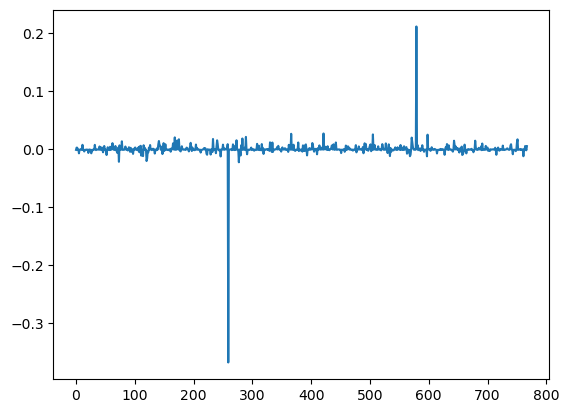

In [38]:
import matplotlib.pyplot as plt

for i in vit.parameters():
    print(i.squeeze((0, 1)).shape)
    plt.plot(i.squeeze((0, 1)).cpu().detach().numpy())
    break